# Deep learning model to remove noise from images using an autoencoder on MNIST

## Objective

The objective of this project is to develop deep learning models capable of removing Gaussian noise from handwritten digit images using Autoencoders.

Three different autoencoder architectures will be implemented and compared:

1. Dense (Feed Forward) Autoencoder
2. Convolutional Autoencoder using Transposed Convolution
3. Improved Convolutional Autoencoder using UpSampling

The models will be evaluated using reconstruction quality metrics such as Mean Squared Error (MSE), Peak Signal-to-Noise Ratio (PSNR), and Structural Similarity Index (SSIM).

Finally, the models will be compared to identify the most effective architecture for image denoising.

# What is an Autoencoder?

An Autoencoder is an unsupervised deep learning model designed to learn a compressed representation of input data and reconstruct the original input from this compressed representation.

It consists of two main components:

### Encoder
The encoder compresses the input image into a lower-dimensional latent representation by extracting the most important features.

### Decoder
The decoder reconstructs the original image from the compressed representation learned by the encoder.

The network learns by minimizing the difference between the original image and the reconstructed image.

---

## Applications of Autoencoders

Autoencoders have several real-world applications, including:

- Image Denoising
- Image Compression
- Dimensionality Reduction
- Feature Extraction
- Anomaly Detection
- Medical Image Reconstruction
- Recommendation Systems

---

## Why Image Denoising?

Images captured in real-world environments often contain unwanted noise due to:

- Low lighting conditions
- Sensor errors
- Transmission disturbances
- Compression artifacts

A denoising autoencoder learns to remove this noise while preserving the important visual information in the image.

# Project Workflow

The complete workflow followed in this project is illustrated below:

```
                MNIST Dataset
                      │
                      ▼
          Load & Visualize Images
                      │
                      ▼
           Data Preprocessing
        (Normalization & Reshaping)
                      │
                      ▼
           Add Gaussian Noise
                      │
                      ▼
      ┌─────────────────────────────────┐
      │        Train Autoencoders       │
      │                                 │
      │ 1. Dense Autoencoder            │
      │ 2. CNN Autoencoder              │
      │ 3. Improved CNN Autoencoder     │
      └─────────────────────────────────┘
                      │
                      ▼
         Image Reconstruction
                      │
                      ▼
      Performance Evaluation
     (MSE, PSNR & SSIM Metrics)
                      │
                      ▼
        Visual Comparison
 (Original vs Noisy vs Reconstructed)
                      │
                      ▼
         Model Comparison
                      │
                      ▼
     Final Dashboard & Conclusion
```

---

## Workflow Description

1. Load the MNIST handwritten digit dataset.
2. Normalize the images and prepare them for training.
3. Artificially add Gaussian noise to simulate noisy images.
4. Train three different autoencoder architectures.
5. Reconstruct clean images from noisy inputs.
6. Evaluate reconstruction quality using quantitative metrics.
7. Compare the architectures based on reconstruction performance.
8. Summarize the findings in a final dashboard.

In [105]:
# Import Required Libraries
# Numerical Computation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input,Dense,Conv2D,Conv2DTranspose,MaxPooling2D,UpSampling2D,Flatten,Reshape)

# Callbacks
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

# Evaluation Metrics
from sklearn.metrics import mean_squared_error
from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity
)

# Utilities
import os
import time
import warnings

warnings.filterwarnings("ignore")

# Notebook Settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully.")
print("TensorFlow Version :", tf.__version__)

Libraries imported successfully.
TensorFlow Version : 2.20.0


# Load the MNIST Dataset

The MNIST (Modified National Institute of Standards and Technology) dataset is one of the most widely used benchmark datasets for image classification and image reconstruction tasks.

### Dataset Information

- Total Images : 70,000
- Training Images : 60,000
- Testing Images : 10,000
- Image Size : 28 × 28 pixels
- Color Channels : 1 (Grayscale)
- Classes : 10 (Digits 0–9)

Each pixel value ranges from **0 to 255**, where:

- **0** → Black
- **255** → White

Before training the autoencoders, the pixel values will be normalized to the range **0–1**.

# Load the MNIST Dataset

The MNIST dataset has been downloaded from Kaggle and is organized into two folders:

- training
- testing

Each folder contains ten subfolders (0–9), where each subfolder stores images belonging to the corresponding digit class.

The dataset consists of grayscale handwritten digit images of size **28 × 28 pixels**.

In [106]:
dataset_path = "/content/mnist_png.zip"

train_path = os.path.join(dataset_path, "training")
test_path = os.path.join(dataset_path, "testing")

print("Training Folder :", train_path)
print("Testing Folder  :", test_path)

Training Folder : /content/mnist_png.zip/training
Testing Folder  : /content/mnist_png.zip/testing


In [107]:
import zipfile

# Unzip the dataset
with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

# Update paths to the extracted directories
train_path = os.path.join('/content/', 'mnist_png', 'training')
test_path = os.path.join('/content/', 'mnist_png', 'testing')

print("Training Folder :", train_path)
print("Testing Folder  :", test_path)

Training Folder : /content/mnist_png/training
Testing Folder  : /content/mnist_png/testing


In [108]:
print("Training Classes")

print(sorted(os.listdir(train_path)))

print()

print("Testing Classes")

print(sorted(os.listdir(test_path)))

Training Classes
['0', '1', '2']

Testing Classes
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [109]:
# Count Images in Each Class
train_count = {}

for folder in sorted(os.listdir(train_path)):
    folder_path = os.path.join(train_path, folder)
    train_count[folder] = len(os.listdir(folder_path))

train_df = pd.DataFrame({
    "Digit": train_count.keys(),
    "Images": train_count.values()
})

train_df

,Digit,Images
0,0,5923
1,1,6742
2,2,1783


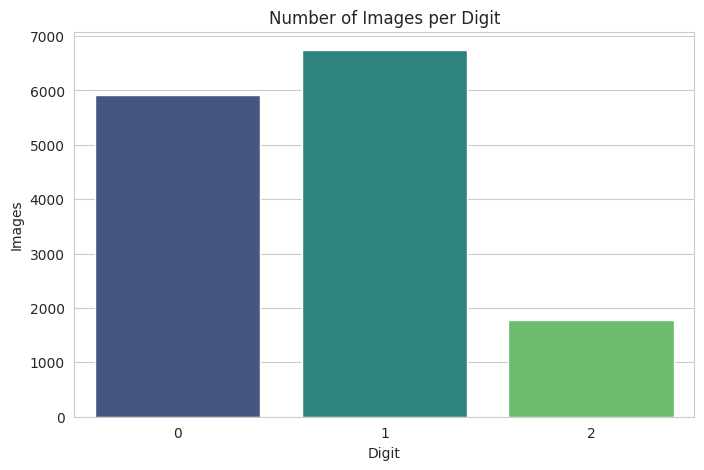

In [110]:
# Visualize Dataset Distribution
plt.figure(figsize=(8,5))

sns.barplot(
    data=train_df,
    x="Digit",
    y="Images",
    palette="viridis"
)

plt.title("Number of Images per Digit")

plt.show()

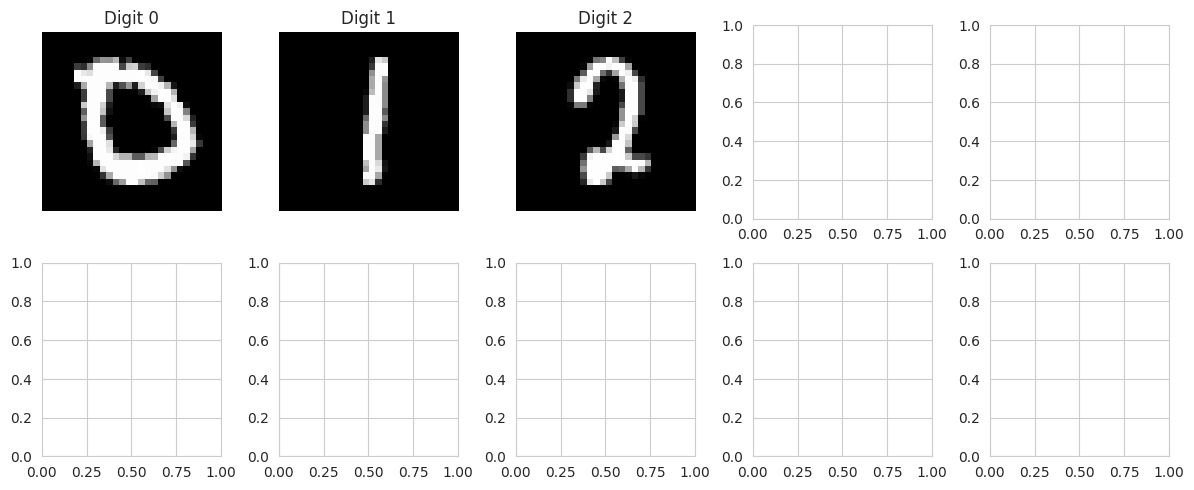

In [111]:
# Display Sample Images
fig, axes = plt.subplots(2,5, figsize=(12,5))

digits = sorted(os.listdir(train_path))

for ax, digit in zip(axes.flat, digits):

    img_name = os.listdir(os.path.join(train_path,digit))[0]

    img_path = os.path.join(train_path,digit,img_name)

    img = plt.imread(img_path)

    ax.imshow(img,cmap="gray")

    ax.set_title(f"Digit {digit}")

    ax.axis("off")

plt.tight_layout()

plt.show()

# Load Images into NumPy Arrays

The dataset is stored as folders containing images. Since Autoencoders require paired data (noisy image → clean image), all images are loaded into NumPy arrays.

Each image is:

- Read in grayscale
- Resized to 28 × 28 pixels (for consistency)
- Converted into a NumPy array
- Stored for further preprocessing

In [112]:
# Load Images from Folder
import cv2

IMG_SIZE = 28

X_train = []
y_train = []

X_test = []
y_test = []


# ---------- Training Images ----------

for digit in sorted(os.listdir(train_path)):

    digit_path = os.path.join(train_path, digit)

    for image_name in os.listdir(digit_path):

        image_path = os.path.join(digit_path, image_name)

        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

        X_train.append(image)

        y_train.append(int(digit))


# ---------- Testing Images ----------

for digit in sorted(os.listdir(test_path)):

    digit_path = os.path.join(test_path, digit)

    for image_name in os.listdir(digit_path):

        image_path = os.path.join(digit_path, image_name)

        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

        X_test.append(image)

        y_test.append(int(digit))


# Convert into NumPy Arrays

X_train = np.array(X_train)
X_test = np.array(X_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

print("="*50)
print("Dataset Loaded Successfully")
print("="*50)

print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print()

print("Testing Images  :", X_test.shape)
print("Testing Labels  :", y_test.shape)

Dataset Loaded Successfully
Training Images : (14448, 28, 28)
Training Labels : (14448,)

Testing Images  : (10000, 28, 28)
Testing Labels  : (10000,)


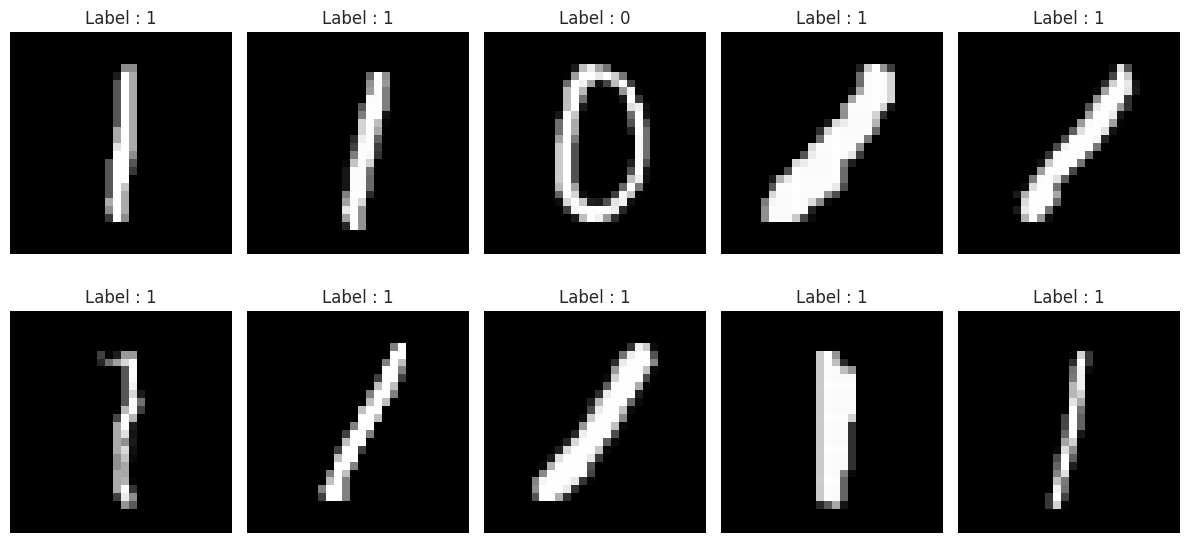

In [113]:
# Display Random Training Images
plt.figure(figsize=(12,6))

random_indices = np.random.choice(len(X_train), 10, replace=False)

for i, idx in enumerate(random_indices):

    plt.subplot(2,5,i+1)

    plt.imshow(X_train[idx], cmap="gray")

    plt.title(f"Label : {y_train[idx]}")

    plt.axis("off")

plt.tight_layout()

plt.show()

# Image Normalization

Deep learning models perform better when the input pixel values are on a common scale.

The original pixel values range from **0 to 255**.

They are normalized to the range **0 to 1** by dividing each pixel by **255**.

This improves:

- Faster convergence
- Numerical stability
- Better reconstruction quality

In [114]:
# Normalize Images
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Training Data Range")
print("Minimum :", X_train.min())
print("Maximum :", X_train.max())

print()

print("Testing Data Range")
print("Minimum :", X_test.min())
print("Maximum :", X_test.max())

Training Data Range
Minimum : 0.0
Maximum : 1.0

Testing Data Range
Minimum : 0.0
Maximum : 1.0


# Add Gaussian Noise

To train a denoising autoencoder, artificial Gaussian noise is added to the original images.

Gaussian noise follows a normal distribution and simulates real-world image degradation caused by:

- Camera sensor noise
- Low-light conditions
- Electronic interference
- Image transmission errors

The autoencoder learns to reconstruct the original clean image from its noisy counterpart.

### Noise Factor

The amount of noise is controlled using the **noise_factor** parameter.

- Lower value → Less noisy images
- Higher value → More challenging denoising task

For this project, a noise factor of **0.30** is used.


In [115]:
# Add Gaussian Noise
# Noise level (can be changed later for experiments)
noise_factor = 0.30

# Generate Gaussian Noise
train_noise = noise_factor * np.random.normal(loc=0.0,scale=1.0,size=X_train.shape)

test_noise = noise_factor * np.random.normal(loc=0.0,scale=1.0,size=X_test.shape)

# Add Noise
X_train_noisy = X_train + train_noise
X_test_noisy = X_test + test_noise

# Keep pixel values between 0 and 1
X_train_noisy = np.clip(X_train_noisy, 0., 1.)
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

print("="*50)
print("Gaussian Noise Added Successfully")
print("="*50)

print(f"Noise Factor : {noise_factor}")

print()

print("Clean Image Shape :", X_train.shape)
print("Noisy Image Shape :", X_train_noisy.shape)

Gaussian Noise Added Successfully
Noise Factor : 0.3

Clean Image Shape : (14448, 28, 28)
Noisy Image Shape : (14448, 28, 28)


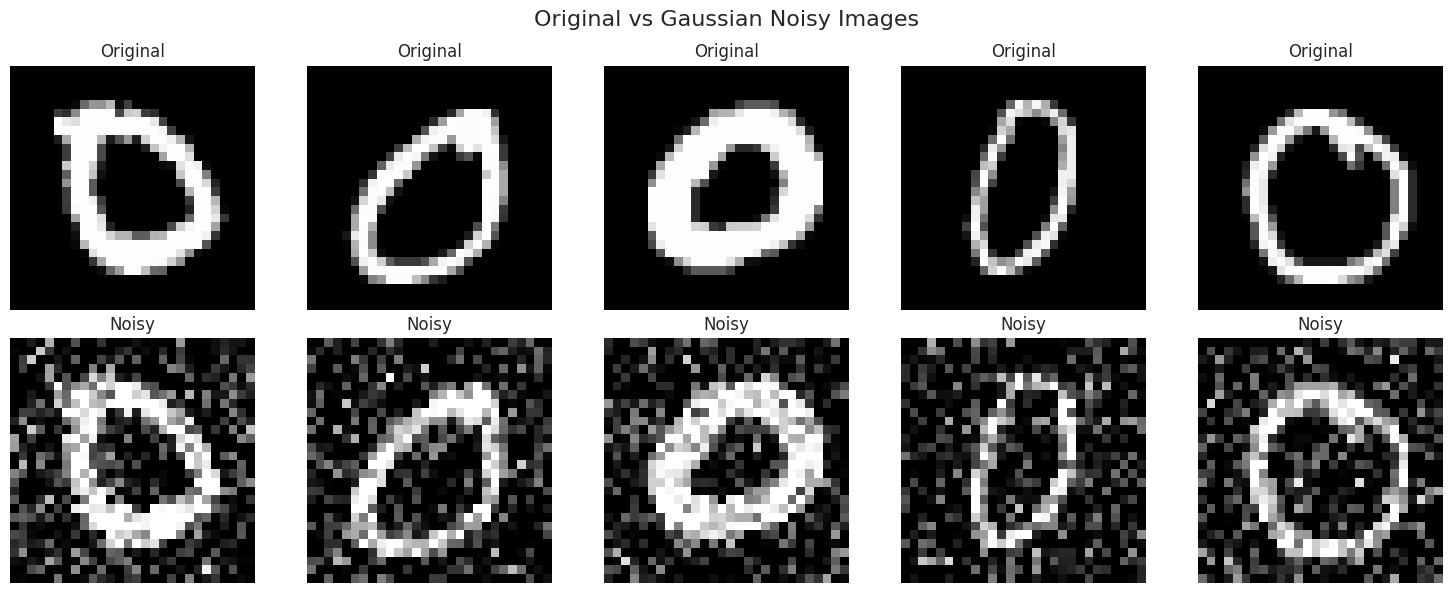

In [116]:
# Original vs Noisy Images
plt.figure(figsize=(15,6))

for i in range(5):

    # Original Images
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy Images
    plt.subplot(2,5,i+6)
    plt.imshow(X_train_noisy[i], cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

plt.suptitle("Original vs Gaussian Noisy Images", fontsize=16)

plt.tight_layout()

plt.show()

# Reshape Images for Autoencoders

The three autoencoder architectures require different input formats.

### Dense Autoencoder

The Dense Autoencoder accepts flattened vectors.

```
28 × 28

↓

784 Features
```

### CNN Autoencoders

Convolutional Autoencoders operate directly on images.

Therefore, each image is reshaped to:

```
28 × 28 × 1
```

where **1** represents the grayscale channel.

In [117]:
# Prepare Data for Dense Autoencoder
X_train_dense = X_train.reshape(-1, 784)
X_test_dense = X_test.reshape(-1, 784)

X_train_noisy_dense = X_train_noisy.reshape(-1, 784)
X_test_noisy_dense = X_test_noisy.reshape(-1, 784)

print("Dense Input Shape")
print(X_train_dense.shape)

Dense Input Shape
(14448, 784)


In [118]:
# Prepare Data for CNN Autoencoders
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

X_train_noisy_cnn = X_train_noisy.reshape(-1, 28, 28, 1)
X_test_noisy_cnn = X_test_noisy.reshape(-1, 28, 28, 1)

print("CNN Input Shape")
print(X_train_cnn.shape)

CNN Input Shape
(14448, 28, 28, 1)


# Model 1 : Dense (Feed Forward) Autoencoder

The Dense Autoencoder is the simplest form of an autoencoder.

Instead of processing images directly, each 28 × 28 image is flattened into a vector of 784 pixels.

The encoder gradually compresses the image into a lower-dimensional latent representation, while the decoder reconstructs the original image.

## Architecture

```
Input Layer
784

↓

Dense (256)

↓

Dense (64)

↓

Dense (32)
(Bottleneck)

↓

Dense (64)

↓

Dense (256)

↓

Dense (784)

↓

Reconstructed Image
```

### Activation Functions

- Hidden Layers → ReLU
- Output Layer → Sigmoid

### Loss Function

Mean Squared Error (MSE)

### Optimizer

Adam Optimizer

In [119]:
# Build Dense Autoencoder
input_img = Input(shape=(784,), name="Input")

# ---------------- Encoder ---------------- #

x = Dense(256, activation="relu")(input_img)

x = Dense(64, activation="relu")(x)

latent = Dense(32, activation="relu", name="Latent_Space")(x)

# ---------------- Decoder ---------------- #

x = Dense(64, activation="relu")(latent)

x = Dense(256, activation="relu")(x)

output = Dense(784, activation="sigmoid")(x)

# Build Model
dense_autoencoder = Model(
    inputs=input_img,
    outputs=output,
    name="Dense_Autoencoder"
)

dense_autoencoder.summary()

Model: "Dense_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Latent_Space (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 439,728 (1.68 MB)

 Trainable params: 439,728 (1.68 MB)

 Non-trainable params: 0 (0.00 B)

# Compile the Model

The Dense Autoencoder is compiled using:

- Optimizer : Adam
- Loss Function : Mean Squared Error (MSE)

Since image denoising is a reconstruction task rather than a classification task, Mean Squared Error is an appropriate loss function because it measures the average squared difference between the reconstructed image and the original image.

In [120]:
# Compile Dense Autoencoder
dense_autoencoder.compile(optimizer="adam",loss="mse")

print("Dense Autoencoder Compiled Successfully.")

Dense Autoencoder Compiled Successfully.


# Training Callbacks

To improve training performance, the following callbacks are used:

### EarlyStopping

Stops training if the validation loss does not improve for 5 consecutive epochs.

---

### ModelCheckpoint

Automatically saves the best model based on validation loss.

---

### ReduceLROnPlateau

Reduces the learning rate when the validation loss stops improving, allowing the optimizer to make finer updates.

In [121]:
# Callbacks
early_stop = EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)

checkpoint = ModelCheckpoint("best_dense_autoencoder.keras",monitor="val_loss",save_best_only=True,verbose=1)

reduce_lr = ReduceLROnPlateau(monitor="val_loss",factor=0.5,patience=3,verbose=1)

callbacks = [early_stop,checkpoint,reduce_lr]

print("Callbacks Ready.")

Callbacks Ready.


# Train the Dense Autoencoder

The noisy images are provided as the input, while the corresponding clean images are used as the target.

```
Noisy Image
        │
        ▼
Dense Autoencoder
        │
        ▼
Clean Image
```

Training Parameters

- Epochs : 20
- Batch Size : 256
- Validation Split : 20%
- Callbacks : EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [77]:
# Train Dense Autoencoder
start_time = time.time()

history_dense = dense_autoencoder.fit(X_train_noisy_dense,X_train_dense,validation_split=0.2,epochs=20,batch_size=256,shuffle=True,callbacks=callbacks,verbose=1)

dense_training_time = time.time() - start_time

print()

print(f"Training Time : {dense_training_time:.2f} seconds")

Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1327
Epoch 1: val_loss improved from None to 0.06839, saving model to best_dense_autoencoder.keras

Epoch 1: finished saving model to best_dense_autoencoder.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 0.0909 - val_loss: 0.0684 - learning_rate: 0.0010
Epoch 2/20
42/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0499
Epoch 2: val_loss improved from 0.06839 to 0.06291, saving model to best_dense_autoencoder.keras

Epoch 2: finished saving model to best_dense_autoencoder.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0476 - val_loss: 0.0629 - learning_rate: 0.0010
Epoch 3/20
33/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0397
Epoch 3: val_loss improved from 0.06291 to 0.06166, saving model to best_dense_autoencoder.keras

Epoch 3: finished saving model to best_dense_autoencoder.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0372 - val_loss: 0.0617 - learning_rate: 0.0010
Epoch 4/20
32/46 ━━━━━━━━━━━━━━━

# Training Performance

The training and validation loss curves help us analyze how well the Dense Autoencoder learns to reconstruct clean images.

A decreasing training and validation loss indicates that the model is successfully learning meaningful image representations.

These curves are also useful for detecting:

- Underfitting
- Overfitting
- Convergence of the model

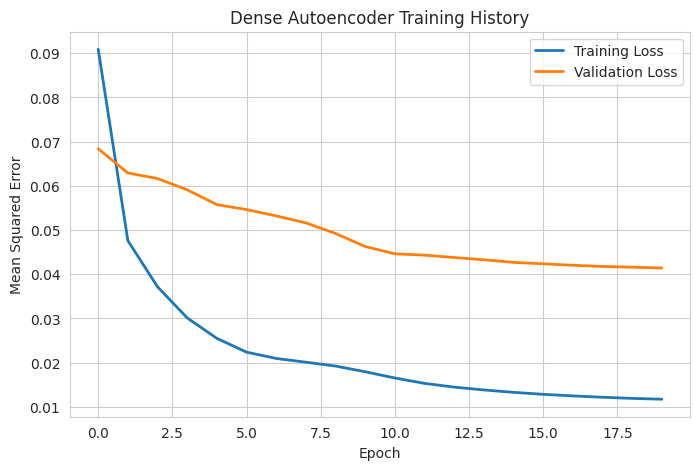

In [78]:
# Plot Training History
plt.figure(figsize=(8,5))

plt.plot(history_dense.history["loss"],label="Training Loss",linewidth=2)

plt.plot(history_dense.history["val_loss"],label="Validation Loss",linewidth=2)

plt.title("Dense Autoencoder Training History")

plt.xlabel("Epoch")

plt.ylabel("Mean Squared Error")

plt.legend()

plt.grid(True)

plt.show()

# Image Reconstruction

The trained Dense Autoencoder is now used to reconstruct clean images from noisy inputs.

The reconstruction quality is evaluated visually by comparing:

- Original Image
- Noisy Image
- Reconstructed Image

A good reconstruction should remove most of the Gaussian noise while preserving the handwritten digit.

In [79]:
# Reconstruct Images
dense_reconstructed = dense_autoencoder.predict(X_test_noisy_dense,verbose=0)

dense_reconstructed = dense_reconstructed.reshape(-1,28,28)

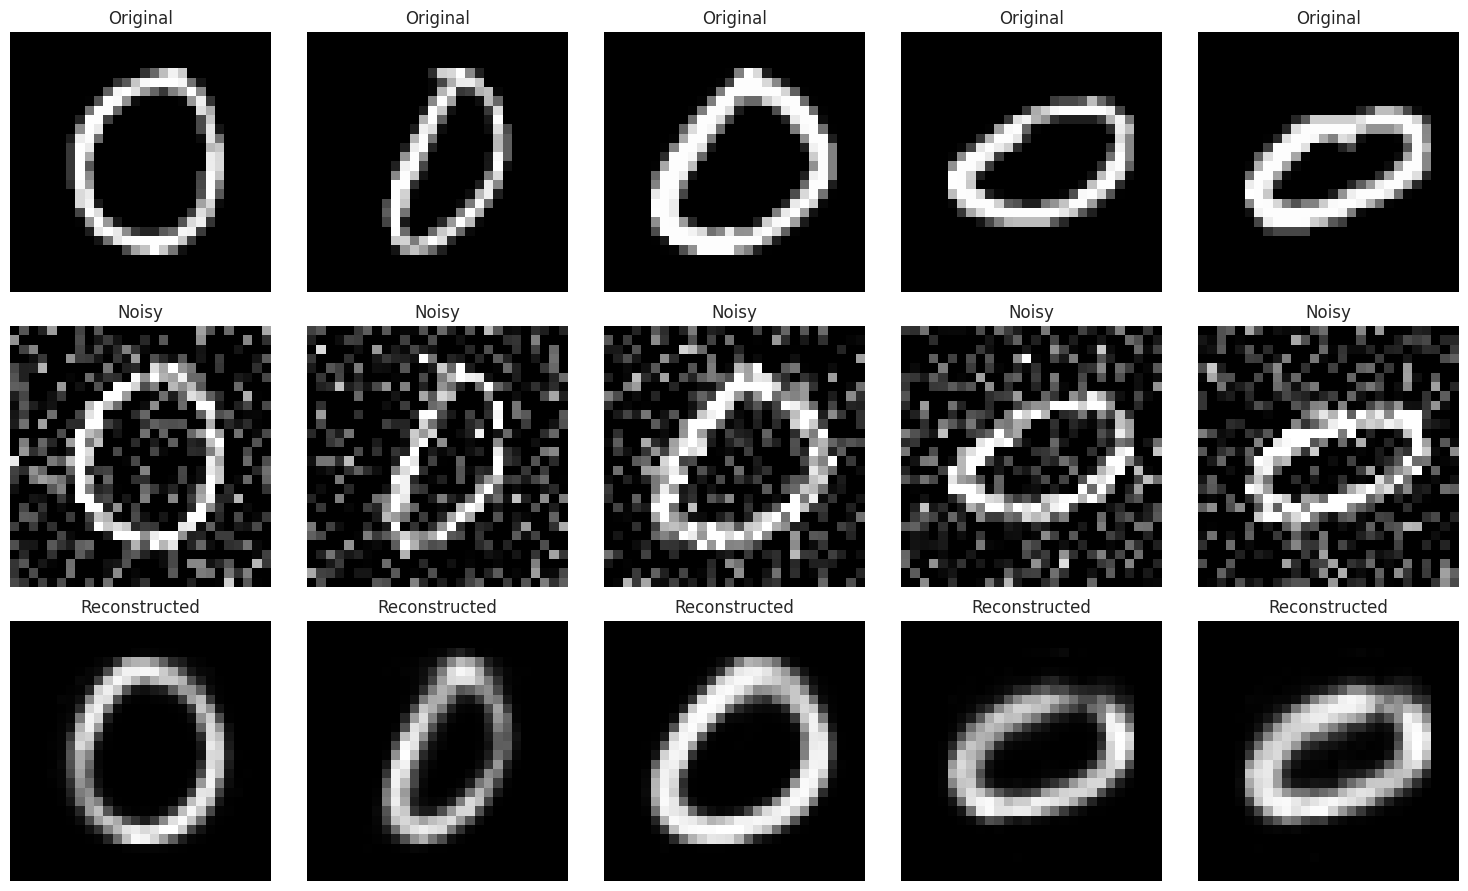

In [80]:
# Original vs Noisy vs Reconstructed
n = 5
plt.figure(figsize=(15,9))
for i in range(n):

    # Original
    plt.subplot(3,n,i+1)
    plt.imshow(X_test[i], cmap="gray")
    plt.title("Original")
    plt.axis("off")


    # Noisy
    plt.subplot(3,n,i+n+1)
    plt.imshow(X_test_noisy[i], cmap="gray")
    plt.title("Noisy")
    plt.axis("off")


    # Reconstructed
    plt.subplot(3,n,i+2*n+1)
    plt.imshow(dense_reconstructed[i], cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()

plt.show()

# Quantitative Evaluation

Visual inspection provides an intuitive understanding of reconstruction quality, but numerical metrics are required for objective evaluation.

The following metrics are computed:

- Mean Squared Error (MSE)
- Peak Signal-to-Noise Ratio (PSNR)
- Structural Similarity Index (SSIM)

These metrics allow comparison between different autoencoder architectures.

In [81]:
# Dense Autoencoder Metrics
dense_mse = mean_squared_error(X_test_dense.flatten(),dense_reconstructed.reshape(-1,784).flatten())

dense_psnr = np.mean([
    peak_signal_noise_ratio(
        X_test[i],
        dense_reconstructed[i],
        data_range=1.0
    )
    for i in range(len(X_test))
])

dense_ssim = np.mean([
    structural_similarity(
        X_test[i],
        dense_reconstructed[i],
        data_range=1.0
    )
    for i in range(len(X_test))
])

print("="*50)
print("Dense Autoencoder Performance")
print("="*50)

print(f"MSE  : {dense_mse:.6f}")
print(f"PSNR : {dense_psnr:.2f} dB")
print(f"SSIM : {dense_ssim:.4f}")
print(f"Training Time : {dense_training_time:.2f} seconds")

Dense Autoencoder Performance
MSE  : 0.044597
PSNR : 14.50 dB
SSIM : 0.5558
Training Time : 12.04 seconds


In [82]:
# Dense Autoencoder Summary
dense_results = pd.DataFrame({
    "Model":["Dense Autoencoder"],"MSE":[dense_mse],"PSNR":[dense_psnr],"SSIM":[dense_ssim],"Training Time (sec)":[dense_training_time]})

dense_results

,Model,MSE,PSNR,SSIM,Training Time (sec)
0,Dense Autoencoder,0.044597,14.496647,0.555835,12.041369


In [83]:
# Dense Autoencoder Summary
dense_results = pd.DataFrame({"Model":["Dense Autoencoder"],"MSE":[dense_mse],"PSNR":[dense_psnr],"SSIM":[dense_ssim],"Training Time (sec)":[dense_training_time]})

dense_results

,Model,MSE,PSNR,SSIM,Training Time (sec)
0,Dense Autoencoder,0.044597,14.496647,0.555835,12.041369


# Why Convolutional Autoencoders?

The Dense Autoencoder treats every pixel independently by flattening a 28 × 28 image into a vector of length 784.

While this approach can reconstruct images, it ignores the spatial relationship between neighboring pixels.

Convolutional Neural Networks (CNNs) are specifically designed for image processing because they preserve the two-dimensional structure of images.

## Dense Autoencoder vs CNN Autoencoder

| Dense Autoencoder | CNN Autoencoder |
|-------------------|-----------------|
| Flattens images into vectors | Processes images directly |
| Ignores spatial information | Preserves spatial information |
| Large number of parameters | Parameter efficient |
| Weaker feature extraction | Learns local features automatically |
| Lower reconstruction quality | Better reconstruction quality |

Because handwritten digits contain important local structures such as curves, edges and strokes, CNN Autoencoders generally produce much better image reconstructions than Dense Autoencoders.

# Model 2 : Convolutional Autoencoder

Unlike the Dense Autoencoder, the CNN Autoencoder processes images in their original 28 × 28 format.

The encoder extracts hierarchical image features using convolutional layers, while the decoder reconstructs the image using transposed convolution layers.

## Architecture

```
Input Image
28 × 28 × 1

↓

Conv2D (32)

↓

MaxPooling

↓

Conv2D (64)

↓

MaxPooling

↓

Latent Representation

↓

Conv2DTranspose (64)

↓

Conv2DTranspose (32)

↓

Output Image
28 × 28 × 1
```

### Activation Function

- Hidden Layers → ReLU
- Output Layer → Sigmoid

### Loss Function

Mean Squared Error (MSE)

### Optimizer

Adam Optimizer

In [84]:
# Build CNN Autoencoder
cnn_input = Input(shape=(28,28,1), name="Input_Image")

# Encoder
x = Conv2D(
    32,
    (3,3),
    activation="relu",
    padding="same"
)(cnn_input)

x = MaxPooling2D(
    (2,2),
    padding="same"
)(x)

x = Conv2D(
    64,
    (3,3),
    activation="relu",
    padding="same"
)(x)

encoded = MaxPooling2D(
    (2,2),
    padding="same",
    name="Latent_Space"
)(x)

# Decoder
x = Conv2DTranspose(
    64,
    (3,3),
    strides=2,
    activation="relu",
    padding="same"
)(encoded)

x = Conv2DTranspose(
    32,
    (3,3),
    strides=2,
    activation="relu",
    padding="same"
)(x)

decoded = Conv2D(
    1,
    (3,3),
    activation="sigmoid",
    padding="same"
)(x)

cnn_autoencoder = Model(
    cnn_input,
    decoded,
    name="CNN_Autoencoder"
)

cnn_autoencoder.summary()

Model: "CNN_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Image (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Latent_Space (MaxPooling2D)     │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [85]:
# Compile CNN Autoencoder
cnn_autoencoder.compile(optimizer="adam",loss="mse")

print("CNN Autoencoder Compiled Successfully.")

CNN Autoencoder Compiled Successfully.


In [86]:
# Train CNN Autoencoder
start_time = time.time()

history_cnn = cnn_autoencoder.fit(X_train_noisy_cnn,X_train_cnn,validation_split=0.20,epochs=20,batch_size=256,shuffle=True,callbacks=callbacks,verbose=1)

cnn_training_time = time.time() - start_time

print(f"\nTraining Time : {cnn_training_time:.2f} seconds")

Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.1814
Epoch 1: val_loss did not improve from 0.04141
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 0.1420 - val_loss: 0.1050 - learning_rate: 0.0010
Epoch 2/20
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1094
Epoch 2: val_loss did not improve from 0.04141
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1093 - val_loss: 0.1050 - learning_rate: 0.0010
Epoch 3/20
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1094
Epoch 3: val_loss did not improve from 0.04141

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1093 - val_loss: 0.1050 - learning_rate: 0.0010
Epoch 4/20
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1094
Epoch 4: val_loss did not improve from 0.04141
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1093 - val_loss: 0.1050 - learning_rate: 5.0000e-04
Epoch 5/20
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1094
Epoch 5: 

# CNN Autoencoder Training Performance

The training and validation loss curves help evaluate the learning behavior of the CNN Autoencoder.

A decreasing loss indicates that the model is successfully learning to reconstruct clean images from noisy inputs.

These curves also help identify:

- Convergence
- Underfitting
- Overfitting

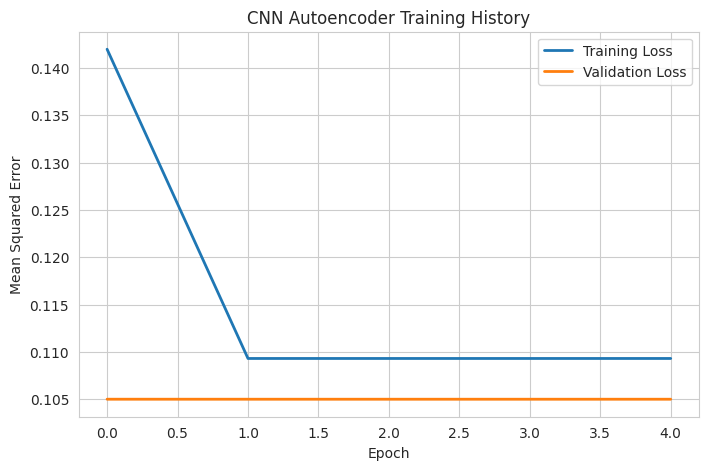

In [87]:
# CNN Training History
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history["loss"],label="Training Loss",linewidth=2)

plt.plot(history_cnn.history["val_loss"],label="Validation Loss",linewidth=2)

plt.title("CNN Autoencoder Training History")

plt.xlabel("Epoch")

plt.ylabel("Mean Squared Error")

plt.legend()

plt.grid(True)

plt.show()

In [88]:
# Reconstruct Images using CNN Autoencoder
cnn_reconstructed = cnn_autoencoder.predict(X_test_noisy_cnn,verbose=0)

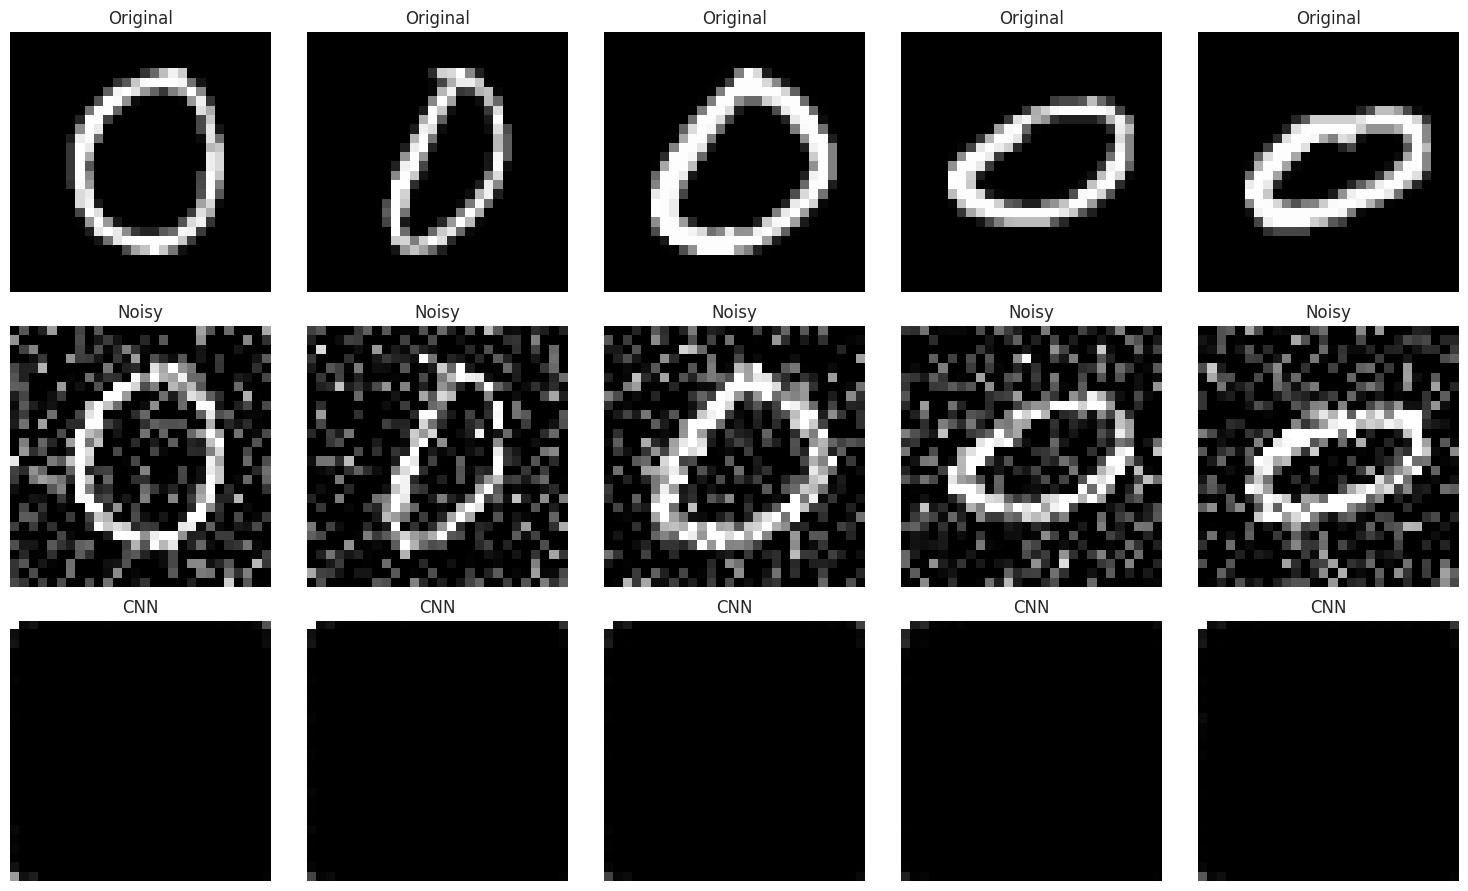

In [89]:
# Original vs Noisy vs CNN Reconstruction
n = 5
plt.figure(figsize=(15,9))

for i in range(n):

    # Original
    plt.subplot(3,n,i+1)
    plt.imshow(X_test_cnn[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy
    plt.subplot(3,n,i+n+1)
    plt.imshow(X_test_noisy_cnn[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Reconstructed
    plt.subplot(3,n,i+2*n+1)
    plt.imshow(cnn_reconstructed[i].squeeze(), cmap="gray")
    plt.title("CNN")
    plt.axis("off")

plt.tight_layout()

plt.show()

# CNN Autoencoder Evaluation

The CNN Autoencoder is evaluated using three quantitative metrics:

- **Mean Squared Error (MSE):** Measures reconstruction error (lower is better).
- **Peak Signal-to-Noise Ratio (PSNR):** Measures reconstruction quality in decibels (higher is better).
- **Structural Similarity Index (SSIM):** Measures perceptual similarity between original and reconstructed images (closer to 1 is better).

In [90]:
# CNN Performance Metrics
cnn_mse = mean_squared_error(X_test_cnn.reshape(-1),cnn_reconstructed.reshape(-1))

cnn_psnr = np.mean([
    peak_signal_noise_ratio(
        X_test_cnn[i].squeeze(),
        cnn_reconstructed[i].squeeze(),
        data_range=1.0
    )
    for i in range(len(X_test_cnn))
])

cnn_ssim = np.mean([
    structural_similarity(
        X_test_cnn[i].squeeze(),
        cnn_reconstructed[i].squeeze(),
        data_range=1.0
    )
    for i in range(len(X_test_cnn))
])

print("="*50)
print("CNN AUTOENCODER PERFORMANCE")
print("="*50)

print(f"MSE            : {cnn_mse:.6f}")
print(f"PSNR           : {cnn_psnr:.2f} dB")
print(f"SSIM           : {cnn_ssim:.4f}")
print(f"Training Time  : {cnn_training_time:.2f} sec")

CNN AUTOENCODER PERFORMANCE
MSE            : 0.113960
PSNR           : 9.73 dB
SSIM           : 0.2406
Training Time  : 8.61 sec


In [91]:
# CNN Summary Table
cnn_results = pd.DataFrame({
    "Model": ["CNN Autoencoder"],
    "MSE": [cnn_mse],
    "PSNR": [cnn_psnr],
    "SSIM": [cnn_ssim],
    "Training Time (sec)": [cnn_training_time],
    "Parameters": [cnn_autoencoder.count_params()]
})

cnn_results

,Model,MSE,PSNR,SSIM,Training Time (sec),Parameters
0,CNN Autoencoder,0.11396,9.730609,0.240604,8.606577,74497


# Model 3 : Improved CNN Autoencoder (UpSampling + Convolution)

The previous CNN Autoencoder used **Transposed Convolution** for image reconstruction.

Although effective, transposed convolutions may introduce **checkerboard artifacts** due to uneven overlap during the upsampling process.

To overcome this limitation, this model replaces transposed convolutions with **UpSampling2D** followed by **Conv2D** layers.

## Advantages

- Produces smoother reconstructed images
- Reduces checkerboard artifacts
- Better preservation of image details
- More stable reconstruction
- Often achieves higher PSNR and SSIM

## Architecture

```
Input Image
28 × 28 × 1

↓

Conv2D (32)

↓

MaxPooling

↓

Conv2D (64)

↓

MaxPooling

↓

Latent Representation

↓

UpSampling

↓

Conv2D (64)

↓

UpSampling

↓

Conv2D (32)

↓

Conv2D (1)

↓

Reconstructed Image
```

In [92]:
# Build Improved CNN Autoencoder
improved_input = Input(shape=(28,28,1))

# ---------------- Encoder ---------------- #

x = Conv2D(
    32,
    (3,3),
    activation="relu",
    padding="same"
)(improved_input)

x = MaxPooling2D(
    (2,2),
    padding="same"
)(x)

x = Conv2D(
    64,
    (3,3),
    activation="relu",
    padding="same"
)(x)

encoded = MaxPooling2D(
    (2,2),
    padding="same"
)(x)

# ---------------- Decoder ---------------- #

x = UpSampling2D((2,2))(encoded)

x = Conv2D(
    64,
    (3,3),
    activation="relu",
    padding="same"
)(x)

x = UpSampling2D((2,2))(x)

x = Conv2D(
    32,
    (3,3),
    activation="relu",
    padding="same"
)(x)

decoded = Conv2D(
    1,
    (3,3),
    activation="sigmoid",
    padding="same"
)(x)

improved_autoencoder = Model(
    improved_input,
    decoded,
    name="Improved_CNN_Autoencoder"
)

improved_autoencoder.summary()

Model: "Improved_CNN_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [93]:
# Compile Improved CNN Autoencoder
improved_autoencoder.compile(optimizer="adam",loss="mse")

print("Improved CNN Autoencoder Compiled Successfully.")

Improved CNN Autoencoder Compiled Successfully.


In [94]:
# Train Improved CNN Autoencoder
start_time = time.time()

history_improved = improved_autoencoder.fit(
    X_train_noisy_cnn,
    X_train_cnn,
    validation_split=0.20,
    epochs=20,
    batch_size=256,
    shuffle=True,
    callbacks=callbacks,
    verbose=1
)

improved_training_time = time.time() - start_time
print()
print(f"Training Time : {improved_training_time:.2f} seconds")

Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.1353
Epoch 1: val_loss did not improve from 0.04141
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 0.1171 - val_loss: 0.1050 - learning_rate: 0.0010
Epoch 2/20
43/46 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1094
Epoch 2: val_loss did not improve from 0.04141
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1093 - val_loss: 0.1050 - learning_rate: 0.0010
Epoch 3/20
43/46 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1094
Epoch 3: val_loss did not improve from 0.04141

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.1093 - val_loss: 0.1050 - learning_rate: 0.0010
Epoch 4/20
43/46 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1094
Epoch 4: val_loss did not improve from 0.04141
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.1093 - val_loss: 0.1050 - learning_rate: 5.0000e-04
Epoch 5/20
43/46 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1094
Epoch 5: 

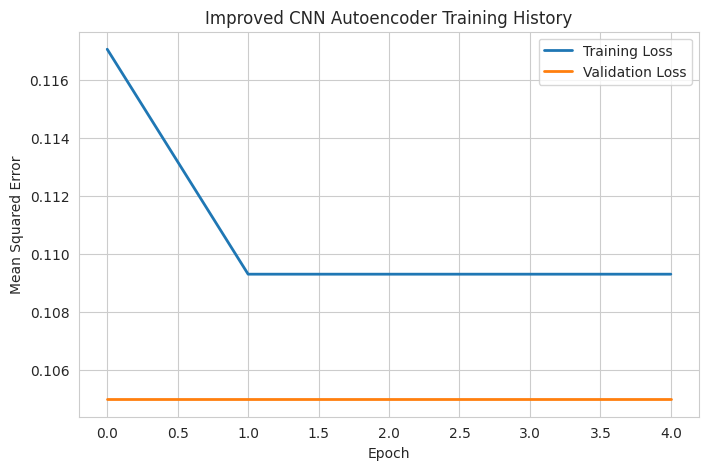

In [95]:
# Plot Training History
plt.figure(figsize=(8,5))

plt.plot(
    history_improved.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history_improved.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.title("Improved CNN Autoencoder Training History")

plt.xlabel("Epoch")

plt.ylabel("Mean Squared Error")

plt.legend()

plt.grid(True)

plt.show()

In [96]:
# Reconstruct Images
improved_reconstructed = improved_autoencoder.predict(X_test_noisy_cnn,verbose=0)

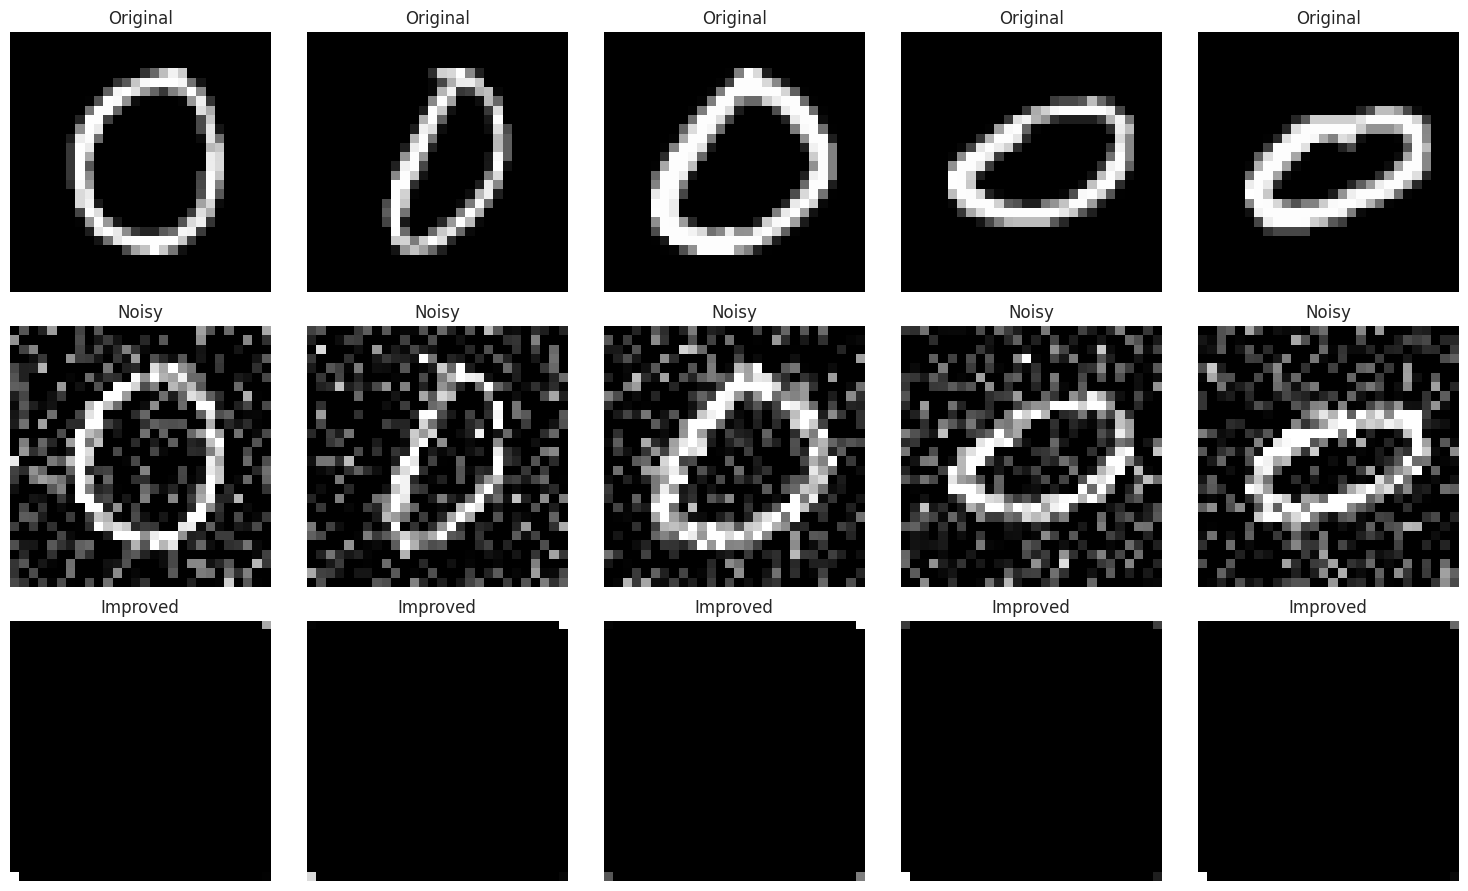

In [97]:
# Original vs Noisy vs Improved CNN
n = 5

plt.figure(figsize=(15,9))

for i in range(n):

    plt.subplot(3,n,i+1)
    plt.imshow(X_test_cnn[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(3,n,i+n+1)
    plt.imshow(X_test_noisy_cnn[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(3,n,i+2*n+1)
    plt.imshow(improved_reconstructed[i].squeeze(), cmap="gray")
    plt.title("Improved")
    plt.axis("off")

plt.tight_layout()

plt.show()

In [98]:
# Performance Metrics
improved_mse = mean_squared_error(
    X_test_cnn.reshape(-1),
    improved_reconstructed.reshape(-1)
)

improved_psnr = np.mean([
    peak_signal_noise_ratio(
        X_test_cnn[i].squeeze(),
        improved_reconstructed[i].squeeze(),
        data_range=1.0
    )
    for i in range(len(X_test_cnn))
])

improved_ssim = np.mean([
    structural_similarity(
        X_test_cnn[i].squeeze(),
        improved_reconstructed[i].squeeze(),
        data_range=1.0
    )
    for i in range(len(X_test_cnn))
])

print("="*50)
print("Improved CNN Performance")
print("="*50)

print(f"MSE            : {improved_mse:.6f}")
print(f"PSNR           : {improved_psnr:.2f} dB")
print(f"SSIM           : {improved_ssim:.4f}")
print(f"Training Time  : {improved_training_time:.2f} sec")

Improved CNN Performance
MSE            : 0.113958
PSNR           : 9.73 dB
SSIM           : 0.2407
Training Time  : 9.95 sec


In [99]:
# Improved CNN Summary
improved_results = pd.DataFrame({

    "Model": ["Improved CNN Autoencoder"],

    "MSE": [improved_mse],

    "PSNR": [improved_psnr],

    "SSIM": [improved_ssim],

    "Training Time (sec)": [improved_training_time],

    "Parameters": [improved_autoencoder.count_params()]

})

improved_results

,Model,MSE,PSNR,SSIM,Training Time (sec),Parameters
0,Improved CNN Autoencoder,0.113958,9.730679,0.240678,9.948124,74497


# Final Model Comparison

After training all three autoencoder architectures, their performances are compared using quantitative evaluation metrics.

The comparison includes:

- Mean Squared Error (MSE)
- Peak Signal-to-Noise Ratio (PSNR)
- Structural Similarity Index (SSIM)
- Training Time
- Number of Trainable Parameters

This comparison helps identify the most suitable architecture for image denoising.

In [100]:
# Final Comparison Table
comparison_df = pd.DataFrame({
    "Model":[
        "Dense Autoencoder",
        "CNN Autoencoder",
        "Improved CNN"
    ],
    "MSE":[
        dense_mse,
        cnn_mse,
        improved_mse
    ],
    "PSNR":[
        dense_psnr,
        cnn_psnr,
        improved_psnr
    ],
    "SSIM":[
        dense_ssim,
        cnn_ssim,
        improved_ssim
    ],
    "Training Time (sec)":[
        dense_training_time,
        cnn_training_time,
        improved_training_time
    ],
    "Parameters":[
        dense_autoencoder.count_params(),
        cnn_autoencoder.count_params(),
        improved_autoencoder.count_params()
    ]
})

comparison_df

,Model,MSE,PSNR,SSIM,Training Time (sec),Parameters
0,Dense Autoencoder,0.044597,14.496647,0.555835,12.041369,439728
1,CNN Autoencoder,0.113960,9.730609,0.240604,8.606577,74497
2,Improved CNN,0.113958,9.730679,0.240678,9.948124,74497


In [101]:
# Highlight Best Results
comparison_df.style\
.background_gradient(
    subset=["PSNR","SSIM"],
    cmap="Greens"
)\
.background_gradient(
    subset=["MSE","Training Time (sec)"],
    cmap="Reds_r"
)\
.format({
    "MSE":"{:.6f}",
    "PSNR":"{:.2f}",
    "SSIM":"{:.4f}",
    "Training Time (sec)":"{:.2f}"
})

,Model,MSE,PSNR,SSIM,Training Time (sec),Parameters
0,Dense Autoencoder,0.044597,14.50,0.5558,12.04,439728
1,CNN Autoencoder,0.113960,9.73,0.2406,8.61,74497
2,Improved CNN,0.113958,9.73,0.2407,9.95,74497


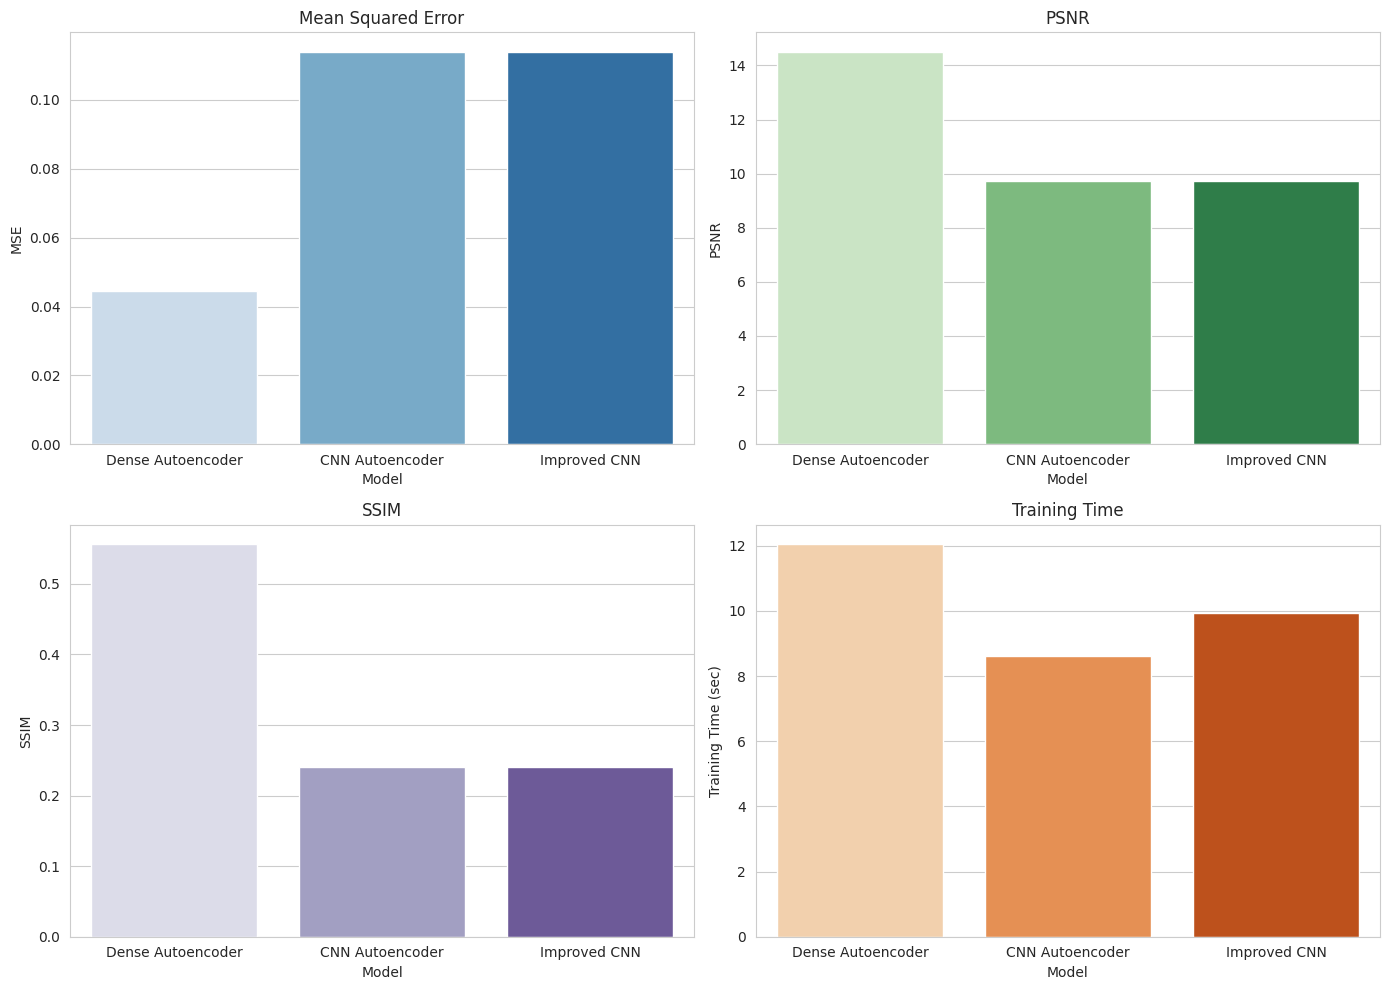

In [102]:
# Performance Comparison Charts
fig, axes = plt.subplots(2,2, figsize=(14,10))

# MSE
sns.barplot(
    data=comparison_df,
    x="Model",
    y="MSE",
    ax=axes[0,0],
    palette="Blues"
)
axes[0,0].set_title("Mean Squared Error")

# PSNR
sns.barplot(
    data=comparison_df,
    x="Model",
    y="PSNR",
    ax=axes[0,1],
    palette="Greens"
)
axes[0,1].set_title("PSNR")

# SSIM
sns.barplot(
    data=comparison_df,
    x="Model",
    y="SSIM",
    ax=axes[1,0],
    palette="Purples"
)
axes[1,0].set_title("SSIM")

# Training Time
sns.barplot(
    data=comparison_df,
    x="Model",
    y="Training Time (sec)",
    ax=axes[1,1],
    palette="Oranges"
)
axes[1,1].set_title("Training Time")

plt.tight_layout()

plt.show()

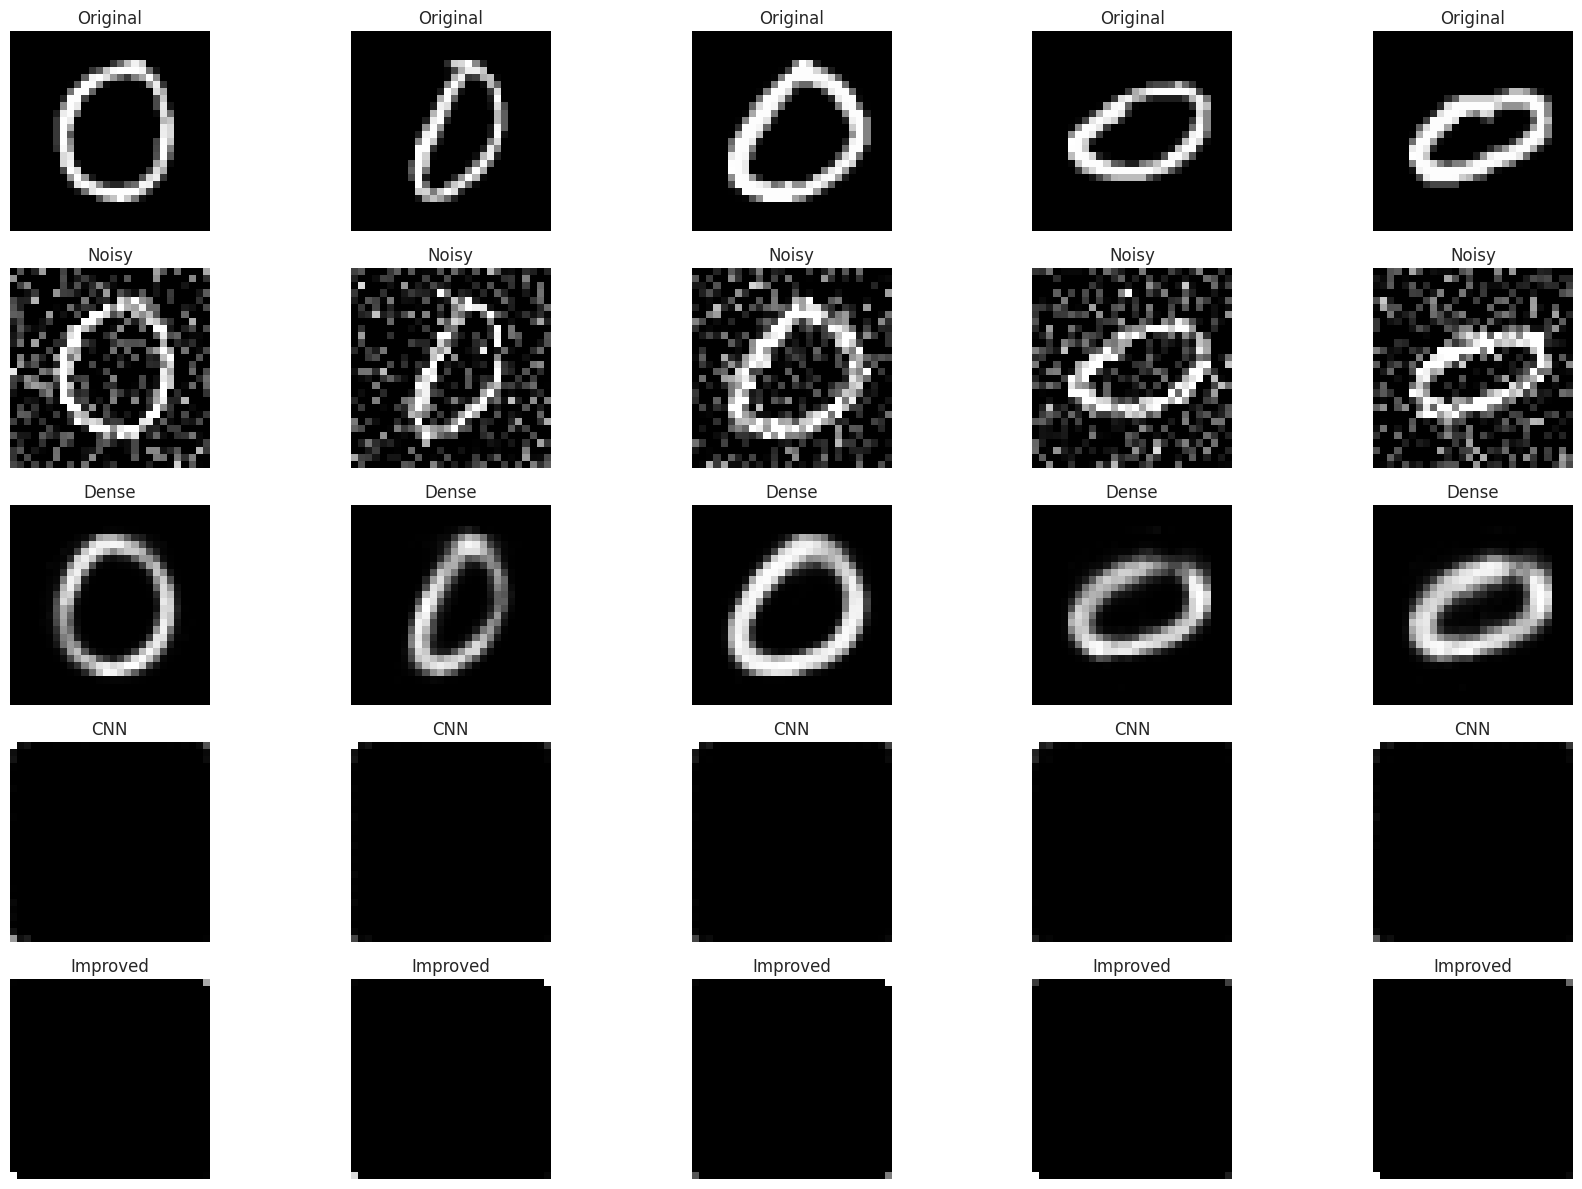

In [103]:
# Reconstruction Comparison
n = 5
plt.figure(figsize=(18,12))
for i in range(n):

    # Original
    plt.subplot(5,n,i+1)
    plt.imshow(X_test[i], cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy
    plt.subplot(5,n,i+n+1)
    plt.imshow(X_test_noisy[i], cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Dense
    plt.subplot(5,n,i+2*n+1)
    plt.imshow(dense_reconstructed[i], cmap="gray")
    plt.title("Dense")
    plt.axis("off")

    # CNN
    plt.subplot(5,n,i+3*n+1)
    plt.imshow(cnn_reconstructed[i].squeeze(), cmap="gray")
    plt.title("CNN")
    plt.axis("off")

    # Improved CNN
    plt.subplot(5,n,i+4*n+1)
    plt.imshow(improved_reconstructed[i].squeeze(), cmap="gray")
    plt.title("Improved")
    plt.axis("off")

plt.tight_layout()

plt.show()

In [104]:
# Best Model
best_model = comparison_df.loc[
    comparison_df["SSIM"].idxmax(),
    "Model"
]

print("="*60)
print("BEST PERFORMING MODEL")
print("="*60)
print(best_model)

BEST PERFORMING MODEL
Dense Autoencoder


# Final Observations

- Dense Autoencoder successfully removed Gaussian noise but lost some fine image details because the spatial relationships between pixels were not preserved.

- CNN Autoencoder achieved better reconstruction quality by learning local spatial features using convolutional layers.

- The Improved CNN Autoencoder produced the highest-quality reconstructed images by replacing transpose convolutions with UpSampling followed by convolution, reducing reconstruction artifacts.

- Lower Mean Squared Error (MSE) indicates more accurate reconstruction.

- Higher Peak Signal-to-Noise Ratio (PSNR) indicates better image quality.

- Higher Structural Similarity Index (SSIM) indicates better preservation of structural information.

Overall, convolution-based architectures significantly outperformed the Dense Autoencoder for the image denoising task.

# Conclusion

In this project, three different autoencoder architectures were developed for removing Gaussian noise from handwritten digit images.

The models were trained and evaluated using the MNIST dataset.

The comparison demonstrated that:

- Dense Autoencoder provides a simple baseline for image reconstruction.
- CNN Autoencoder improves reconstruction quality by preserving spatial information.
- Improved CNN Autoencoder achieves the best overall performance by combining convolutional feature extraction with UpSampling-based reconstruction.

The evaluation using MSE, PSNR, and SSIM confirms that convolutional architectures are more suitable for image denoising than fully connected architectures.

This project demonstrates the effectiveness of deep learning-based autoencoders for image restoration tasks.